In [1]:
import yaml
import numpy as np
import polars as pl
import polars.selectors as cs
from tqdm import tqdm
import statsmodels.api as sm
from scipy import stats

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
# Configuration and paths
mac = 20

# ============================================================
# Variant class selection — change this to switch variant class
# Available: missense, missense_structured, missense_non_structured,
#   missense_disordered, missense_lip, intron,
#   enhancer_encode, promoter_encode, tf_encode, proximal_promoter
# ============================================================
variant_class = 'proximal_promoter'

only_snps = True  # Whether to include only SNPs (exclude indels)

only_clinvar = False
exclude_clinvar = False  # Independent toggle: exclude ClinVar-annotated variants

# Plot params parameters
max_gene_rank = 50   # compute up to this rank within each gene
ci_factor     = 1
target_k = np.array([3, 5, 10], dtype=np.int64)

# Initialize new annotation variable as None
new_anno_local = None

# Load variant class configuration
variant_class_path = "/home/dnanexus/ukbgym/config_variant_classes.yaml"
with open(variant_class_path) as f:
    variant_class_config = yaml.safe_load(f)

vc = variant_class_config[variant_class]
vc_filters = vc['variant_filtering']
selected_categories = vc['tool_categories']
x_label = f"Top N {vc['x_label']} variants"

print(f"Variant class: {variant_class}")
print(f"  Filters: {vc_filters}")
print(f"  Categories: {selected_categories}")
print(f"  X-label: {x_label}")
print(f"  Exclude ClinVar: {exclude_clinvar}")

# Load annotation configuration
config_path = "/home/dnanexus/ukbgym/config_odds.yaml"

with open(config_path) as f:
    config = yaml.safe_load(f)

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

Variant class: proximal_promoter
  Filters: ["(pl.col('vep_cds_relaxed')==False) & (pl.col('mane_cds')==False) & (pl.col('non_mane_cds')==False)", "pl.col('pangolin_score') < 0.2", "pl.col('promoterai_is_na') == False"]
  Categories: ['regulatory', 'conservation']
  X-label: Top N Proximal promoter variants
  Exclude ClinVar: False


category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""missense""","""clinpred_score""","""#FFDC80""","""ClinPred""",1
"""missense""","""bayes_del""","""#FFBF00""","""BayesDel""",1
"""missense""","""polyphen""","""#FF90AA""","""PolyPhen2""",1
"""missense""","""revel_score""","""#FF7000""","""REVEL""",1
"""missense""","""am_pathogenicity""","""#E63946""","""AlphaMissense""",1
…,…,…,…,…
"""regulatory""","""fz_all_max""","""#00A99D""","""Flashzoi max across RNA (all)""",1
"""regulatory""","""abexp_min""","""#1f77b4""","""AbExp min""",1
"""regulatory""","""abexp_max""","""#7CB342""","""AbExp max""",-1


In [3]:
# Get gene trait associations
RAP_DIR = 'project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results'

# ASSOC_FILE = 'loftee_mac20_associations_bh_corrected.parquet'
# ASSOC_FILE = 'regenie_127phenotypes_lofteeHC_mac20_EUR.parquet'
ASSOC_FILE = 'regenie_127phenotypes_lofteeHC_mac20_EUR_miss20per.parquet'

LOCAL_DIR = '/home/dnanexus/data_dir/'

!dx download {RAP_DIR}/{ASSOC_FILE} -o {LOCAL_DIR}

gene_trait_df = (
    pl.read_parquet(f'{LOCAL_DIR}/{ASSOC_FILE}')
    .filter(pl.col('pval_fdr')<=0.05)
    .select(['region', 'phenotype', 'pval_fdr'])
)

# CORR_FILE = 'regenie_127phenotypes_mac20_lofteeHC_EUR_correlations.parquet'
CORR_FILE = "regenie_127phenotypes_lofteeHC_mac20_EUR_miss20per_correlations.parquet"
!dx download {RAP_DIR}/{CORR_FILE} -o {LOCAL_DIR}

loftee_corrs = (
    pl.read_parquet(f'{LOCAL_DIR}/{CORR_FILE}')
    .with_columns(
        loftee_corr = pl.col('correlation'),
        loftee_corr_abs = pl.col('correlation').abs(),
        loftee_corr_dir = pl.col('correlation')/pl.col('correlation').abs(),
    )
    .select(['region', 'phenotype', 'loftee_corr', 'loftee_corr_abs', 'loftee_corr_dir']) 
)

gene_trait_df = (
    gene_trait_df
    .join(loftee_corrs, on=['region', 'phenotype'], how='inner')
    .drop_nans()
    .sort('loftee_corr_abs', descending=True)
    .unique(subset=["region"], keep="first", maintain_order=True)
)
gene_trait_df

Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_lofteeHC_mac20_EUR_
miss20per.parquet" already exists but -f/--overwrite was not set


Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_lofteeHC_mac20_EUR_
miss20per_correlations.parquet" already exists but -f/--overwrite was not set


region,phenotype,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir
str,str,f64,f64,f64,f64
"""ENSG00000084674""","""ldl_direct_int""",2.2543e-301,-0.12678,0.12678,-1.0
"""ENSG00000167701""","""alanine_aminotransferase_int""",1.2234e-144,-0.106424,0.106424,-1.0
"""ENSG00000105610""","""mean_corpuscular_haemoglobin_i…",9.8993e-24,-0.100921,0.100921,-1.0
"""ENSG00000141505""","""alkaline_phosphatase_int""",8.4146e-35,0.089171,0.089171,1.0
"""ENSG00000101162""","""platelet_distribution_width_in…",1.5335e-83,0.08869,0.08869,1.0
…,…,…,…,…,…
"""ENSG00000115977""","""sitting_height_int""",0.021257,-0.001496,0.001496,-1.0
"""ENSG00000119574""","""standing_height_int""",0.025535,-0.001317,0.001317,-1.0
"""ENSG00000115325""","""platelet_distribution_width_in…",0.01277,-0.001204,0.001204,-1.0


In [4]:
# new_anno_path = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/flashzoi_scores"
# new_anno_filename = "ukbbgym_TSS_promoter_enhancer_TF_variants_GENCODEv39_260218_rep0.parquet"
# 89 GTEx tissue tracks:
# choose_cols = ['RNA:adipose_tissue_7522', 'RNA:adipose_tissue_7523', 'RNA:adipose_tissue_7524', 'RNA:adrenal_gland_7525', 'RNA:adrenal_gland_7526', 'RNA:adrenal_gland_7527', 'RNA:bladder_7528', 'RNA:bladder_7529', 'RNA:bladder_7530', 'RNA:blood_7531', 'RNA:blood_7532', 'RNA:blood_7533', 'RNA:blood_vessel_7534', 'RNA:blood_vessel_7535', 'RNA:blood_vessel_7536', 'RNA:bone_marrow_7537', 'RNA:bone_marrow_7538', 'RNA:brain_7539', 'RNA:brain_7540', 'RNA:brain_7541', 'RNA:breast_7542', 'RNA:breast_7543', 'RNA:breast_7544', 'RNA:cervix_uteri_7545', 'RNA:cervix_uteri_7546', 'RNA:cervix_uteri_7547', 'RNA:colon_7548', 'RNA:colon_7549', 'RNA:colon_7550', 'RNA:esophagus_7551', 'RNA:esophagus_7552', 'RNA:esophagus_7553', 'RNA:fallopian_tube_7554', 'RNA:fallopian_tube_7555', 'RNA:fallopian_tube_7556', 'RNA:heart_7557', 'RNA:heart_7558', 'RNA:heart_7559', 'RNA:kidney_7560', 'RNA:kidney_7561', 'RNA:kidney_7562', 'RNA:liver_7563', 'RNA:liver_7564', 'RNA:liver_7565', 'RNA:lung_7566', 'RNA:lung_7567', 'RNA:lung_7568', 'RNA:muscle_7569', 'RNA:muscle_7570', 'RNA:muscle_7571', 'RNA:nerve_7572', 'RNA:nerve_7573', 'RNA:ovary_7574', 'RNA:ovary_7575', 'RNA:ovary_7576', 'RNA:pancreas_7577', 'RNA:pancreas_7578', 'RNA:pancreas_7579', 'RNA:pituitary_7580', 'RNA:pituitary_7581', 'RNA:pituitary_7582', 'RNA:prostate_7583', 'RNA:prostate_7584', 'RNA:prostate_7585', 'RNA:salivary_gland_7586', 'RNA:salivary_gland_7587', 'RNA:salivary_gland_7588', 'RNA:skin_7589', 'RNA:skin_7590', 'RNA:skin_7591', 'RNA:small_intestine_7592', 'RNA:small_intestine_7593', 'RNA:small_intestine_7594', 'RNA:spleen_7595', 'RNA:spleen_7596', 'RNA:spleen_7597', 'RNA:stomach_7598', 'RNA:stomach_7599', 'RNA:stomach_7600', 'RNA:testis_7601', 'RNA:testis_7602', 'RNA:thyroid_7603', 'RNA:thyroid_7604', 'RNA:thyroid_7605', 'RNA:uterus_7606', 'RNA:uterus_7607', 'RNA:vagina_7608', 'RNA:vagina_7609', 'RNA:vagina_7610']

# !dx download {new_anno_path}/{new_anno_filename} -o /home/dnanexus/data_dir/
# new_anno_local = f'/home/dnanexus/data_dir/{new_anno_filename}'

# new_anno_df = (
#     pl.scan_parquet(new_anno_local)
#     .filter(pl.col('region').is_in(gene_trait_df['region'].unique()))
#     .with_columns(
#         fz_all_min = pl.min_horizontal(cs.starts_with('RNA:')),
#         fz_gtex_min = pl.min_horizontal(choose_cols),
#     )
#     .select(['id', 'region', 'fz_all_min', 'fz_gtex_min'])
#     .collect()
# )

new_anno_path = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/"
new_anno_filename = "ukbbgym_core_promoter_variants_phenotype_scored_aggregated.parquet"
choose_cols = ['abs_zscore_diff', 'abs_delta_log10_median_of_exon_medians']

!dx download {new_anno_path}/{new_anno_filename} -o /home/dnanexus/data_dir/
new_anno_local = f'/home/dnanexus/data_dir/{new_anno_filename}'

new_anno_df = (
    pl.scan_parquet(new_anno_local)
    .filter(pl.col('region').is_in(gene_trait_df['region'].unique()))
    
    .select(['id', 'region'] + choose_cols)
    .collect()
)

new_anno_df

Error: path "/home/dnanexus/data_dir/ukbbgym_core_promoter_variants_phenotype_
scored_aggregated.parquet" already exists but -f/--overwrite was not set


/tmp/ipykernel_109738/1740517490.py:32: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


id,region,abs_zscore_diff,abs_delta_log10_median_of_exon_medians
str,str,f64,f64
"""chr10:100734900:G:A""","""ENSG00000075891""",0.04434,0.007099
"""chr10:100734900:G:C""","""ENSG00000075891""",0.04434,0.005921
"""chr10:100734906:G:T""","""ENSG00000075891""",0.059643,0.008179
"""chr10:100734914:T:C""","""ENSG00000075891""",0.058132,0.00735
"""chr10:100734920:G:A""","""ENSG00000075891""",0.053151,0.006433
…,…,…,…
"""chr9:99128413:G:A""","""ENSG00000106799""",0.018944,0.003303
"""chr9:99128424:C:T""","""ENSG00000106799""",0.018782,0.004196
"""chr9:99128427:A:G""","""ENSG00000106799""",0.018944,0.007687


In [5]:
RAP_ANNO_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated"
LOCAL_ANNO_DIR = "/home/dnanexus/data_dir"

# ANNO_FILE = "annotations_fillna_ukbgym_with_mane.parquet"
ANNO_FILE = "annotations_with_all_no_dup.parquet"

!dx download {RAP_ANNO_DIR}/{ANNO_FILE} -o {LOCAL_ANNO_DIR}/{ANNO_FILE}
anno = pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")

# If True, fillna variants are kept but ranked at the bottom of each annotation
# keep_fillna = True  

# Join new annotation if specified above
if new_anno_local is not None:
    anno = (
        anno
        .join(
            new_anno_df.lazy(),
            on=['id', 'region'],
            how='left'
        )
    )

# Build dynamic filters from variant_class.yaml
if vc_filters is not None:
    _dynamic_filters = [eval(f) for f in vc_filters]
else:
    _dynamic_filters = []

if exclude_clinvar:
    _dynamic_filters.append(pl.col('clinical_significance').is_null())
elif only_clinvar:
    _dynamic_filters.append(pl.col('clinical_significance').is_not_null())

if only_snps:
    _dynamic_filters.append((pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)) 

anno = (
    anno
    .with_columns(
        encode_any_tf = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_tf', 'encode_ca-tf']),
        encode_enhancer = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_pels', 'encode_dels']),
        encode_promoter = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_pls', 'encode_ca-h3k4me3']),
    )
    .filter(
        # Always-applied filters
        (pl.col('region').is_in(gene_trait_df['region'].unique())),

        # Dynamic filters from variant_class.yaml + exclude_clinvar
        *_dynamic_filters,
    )
    .with_columns(
        promoterai_abs = pl.col('promoterai').abs(),
        promoterai_under = pl.col('promoterai'),
        promoterai_over = pl.col('promoterai'),
    )
)

# selected_categories is already set from YAML in the config cell
selected_annos = anno_config_df.filter(
    pl.col('category').is_in(selected_categories)
)['annotation'].to_list()

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]
selected_annos = list(set(selected_annos).intersection(set(existing_annos)))
fillna_cols = [c+'_is_na' for c in selected_annos]

anno = (
    anno
    .select(
        set(['id', 'region']).union(set(selected_annos))
    )
    .collect(engine='streaming')
    # .drop_nulls()
)

anno

Error: path "/home/dnanexus/data_dir/annotations_with_all_no_dup.parquet"
already exists but -f/--overwrite was not set


/tmp/ipykernel_109738/3089220689.py:64: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
/tmp/ipykernel_109738/3089220689.py:73: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


region,promoterai_under,abexp_min,mamphylop,promoterai_over,verphylop,priphylop,id,gpn_score,abexp_max,abs_zscore_diff,abs_delta_log10_median_of_exon_medians
str,f32,f32,f32,f32,f32,f32,str,f32,f32,f64,f64
"""ENSG00000036257""",0.0284,-0.036098,-1.305,0.0284,-1.228,0.321,"""chr2:224563330:T:C""",-1.32,0.003431,0.057172,0.00338
"""ENSG00000036257""",0.0035,-0.02703,-0.131,0.0035,-0.112,-0.681,"""chr2:224563371:C:A""",-1.3,0.003431,0.066423,0.00338
"""ENSG00000036257""",0.0056,-0.006189,-1.787,0.0056,-1.898,-0.485,"""chr2:224563450:G:A""",-0.73,0.003431,0.059725,0.00338
"""ENSG00000036257""",0.0126,-0.006438,-0.931,0.0126,-0.634,0.313,"""chr2:224563633:A:G""",-1.16,0.003182,0.066423,0.00338
"""ENSG00000036257""",0.0053,-0.006189,-1.73,0.0053,-1.749,-1.753,"""chr2:224563660:T:C""",1.54,0.003431,0.057979,0.00338
…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000128276""",-0.0192,-0.014724,0.246,-0.0192,0.249,0.244,"""chr22:32357886:C:G""",-0.25,0.0,null,null
"""ENSG00000100241""",-0.0732,-0.061832,3.253,-0.0732,1.584,0.404,"""chr22:50457152:G:A""",-3.47,-0.023447,null,null
"""ENSG00000164379""",-0.0293,-0.032692,-0.05,-0.0293,0.03,-0.564,"""chr6:1312504:C:A""",-4.22,0.0,null,null


In [6]:
anno_fillna = (
    pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")
    .with_columns(
        promoterai_under_is_na = pl.col('promoterai_is_na'),
        promoterai_over_is_na = pl.col('promoterai_is_na'),
    )
)
fillna_cols = set([c+'_is_na' for c in selected_annos]).intersection(set(anno_fillna.collect_schema().names()))

anno_fillna_melted = (
    anno_fillna
    .filter(pl.col('region').is_in(gene_trait_df['region'].unique()))
    .select(['id', 'region'] + list(fillna_cols))
    
    .join(
        anno.select(['id', 'region']).lazy(), 
        on=['id', 'region'], 
        how='semi'
    )
    .unpivot(
        index=["id", "region"],
        on=list(fillna_cols),
        variable_name="annotation",
        value_name="annotation_is_na"
    )
    .filter(
        pl.col('annotation_is_na') == 1
    )
    .with_columns(
        annotation = pl.col('annotation').str.replace('_is_na$', '')
    )
    # .collect(engine='streaming')
)

anno_fillna_melted.head().collect()

/tmp/ipykernel_109738/139545312.py:35: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


id,region,annotation,annotation_is_na
str,str,str,i8


In [7]:
melted_anno = (
    anno.lazy()

    .unpivot(
        index=["id", "region"],
        on=selected_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )

    # Merge with annotation configuration to get direction and filter
    .join(
        anno_config_df.select(["annotation", "category", "annotation_dir"]).lazy(),
        on="annotation",
        how="left"
    )
    .filter(pl.col('category').is_in(selected_categories))
    .unique()

    # Remove null annotation scores
    .drop_nulls('annotation_score')

    # Remove variants for each annotation which are not scored
    .join(
        anno_fillna_melted,
        on=['id', 'region', 'annotation'],
        how='anti'
    )

    # Correct scores by annotation direction
    .with_columns(
        annotation_score_dircor = pl.col('annotation_score') * pl.col("annotation_dir").cast(pl.Float32)
    )

    .collect(engine='streaming')
)

melted_anno

/tmp/ipykernel_109738/631692843.py:39: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


id,region,annotation,annotation_score,category,annotation_dir,annotation_score_dircor
str,str,str,f32,str,i8,f32
"""chr10:122506440:G:A""","""ENSG00000166033""","""priphylop""",0.595,"""conservation""",1,0.595
"""chr10:24723514:G:A""","""ENSG00000107863""","""priphylop""",0.466,"""conservation""",1,0.466
"""chr10:29522855:T:C""","""ENSG00000197321""","""priphylop""",0.4,"""conservation""",1,0.4
"""chr10:29736938:C:G""","""ENSG00000197321""","""priphylop""",-0.588,"""conservation""",1,-0.588
"""chr10:93060413:A:G""","""ENSG00000187553""","""priphylop""",0.475,"""conservation""",1,0.475
…,…,…,…,…,…,…
"""chr8:52714602:T:A""","""ENSG00000023287""","""priphylop""",0.469,"""conservation""",1,0.469
"""chr9:125143678:C:G""","""ENSG00000173611""","""priphylop""",0.398,"""conservation""",1,0.398
"""chr9:32385023:T:C""","""ENSG00000122729""","""priphylop""",0.469,"""conservation""",1,0.469


In [8]:
RAP_APPV_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/avg_pheno_per_var"
LOCAL_APPV_DIR = "/home/dnanexus/data_dir"

APPV_FILE = "quant_pheno_INT_loftee_mac20_EURunrelated_miss20per_appv_small.parquet"

!dx download {RAP_APPV_DIR}/{APPV_FILE} -o {LOCAL_APPV_DIR}/{APPV_FILE}
pheno_appv = pl.scan_parquet(f"{LOCAL_APPV_DIR}/{APPV_FILE}")

# Filter to variants in annotation set and low MAC
anno_keys = anno.select(pl.col('id').unique()).lazy()

pheno_appv = (
    pheno_appv
    .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        (pl.col('n_individuals') <= mac)
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value', 'n_individuals']
    )
)

Error: path "/home/dnanexus/data_dir/quant_pheno_INT_loftee_mac20_EURunrelated
_miss20per_appv_small.parquet" already exists but -f/--overwrite was not set


# Per-gene ranking: Nth variant sliding window

In [9]:
# Rank variants within each (annotation, gene) group using only variants
# that have phenotype data (i.e. survived the join with variant_zscores).
# This avoids the gap problem where globally top-ranked variants may have
# no phenotype data, leaving holes in the per-gene top-N.

# --- Re-ranking bootstrap: join variant z-scores with annotation ranks ---
id_region = anno.select(['id', 'region']).unique().lazy()

# Get variant-level z-scores joined with gene_trait_df
# Direction-correct mean_pheno_value: if loftee_corr_dir == -1, flip the z-score
# Negate so that "deleterious" variants always have positive z-scores
# (olink phenotype is naturally negative for LoF carriers)
variant_zscores = (
    pheno_appv
    .join(id_region, on='id', how='inner')
    .join(gene_trait_df.lazy(), on=['region', 'phenotype'], how='inner')
    .with_columns(
        mean_pheno_value = pl.col('mean_pheno_value') * pl.col('loftee_corr_dir').cast(pl.Float32)
    )
    .select(['id', 'region', 'mean_pheno_value'])
    .collect(engine='streaming')
)

print(f"Variant z-scores: {variant_zscores.shape[0]} variant-gene pairs")

# Assign max rank to tied variants (same annotation score → same rank),
# average their z-scores within each tied group, deduplicate to one row per
# score group, then add a sequential ordinal_rank (no gaps) for plotting.
ranked_zscores_genewise = (
    variant_zscores.lazy()
    .join(
        melted_anno.lazy().select(['id', 'region', 'annotation', 'annotation_score_dircor']),
        on=['id', 'region'],
        how='inner'
    )
    .with_columns(
        gene_rank = pl.col('annotation_score_dircor')
                      .rank(method='max', descending=True)
                      .over(['annotation', 'region'])
                      .cast(pl.Int32)
    )
    .with_columns(
        mean_pheno_value_by_rank = pl.col('mean_pheno_value')
                             .mean()
                             .over(['annotation', 'region', 'gene_rank'])
    )
    .unique(subset=['annotation', 'region', 'gene_rank'], keep='any')
    .sort(['annotation', 'region', 'gene_rank'])
    .with_columns(
        ordinal_rank = (pl.int_range(pl.len()).over(['annotation', 'region']) + 1).cast(pl.Int32)
    )
    .collect(engine='streaming')
)

ranked_zscores_genewise

Variant z-scores: 390569 variant-gene pairs


id,region,mean_pheno_value,annotation,annotation_score_dircor,gene_rank,mean_pheno_value_by_rank,ordinal_rank
str,str,f32,str,f32,i32,f32,i32
"""chr1:23077383:G:A""","""ENSG00000004487""",-0.134992,"""abexp_max""",0.242312,1,-0.134992,1
"""chr1:23019546:G:A""","""ENSG00000004487""",-0.979637,"""abexp_max""",0.076079,19,-0.031489,2
"""chr1:23019457:G:C""","""ENSG00000004487""",-0.051966,"""abexp_max""",0.059739,20,-0.051966,3
"""chr1:23019581:G:C""","""ENSG00000004487""",0.634769,"""abexp_max""",0.059635,22,0.454897,4
"""chr1:23077385:A:C""","""ENSG00000004487""",-0.228274,"""abexp_max""",0.051702,23,-0.228274,5
…,…,…,…,…,…,…,…
"""chr2:233712816:C:T""","""ENSG00000288705""",0.200036,"""verphylop""",-2.557,118,0.200036,101
"""chr2:233712954:G:A""","""ENSG00000288705""",0.410016,"""verphylop""",-2.697,119,0.410016,102
"""chr2:233712788:A:C""","""ENSG00000288705""",0.788781,"""verphylop""",-2.801,120,0.788781,103


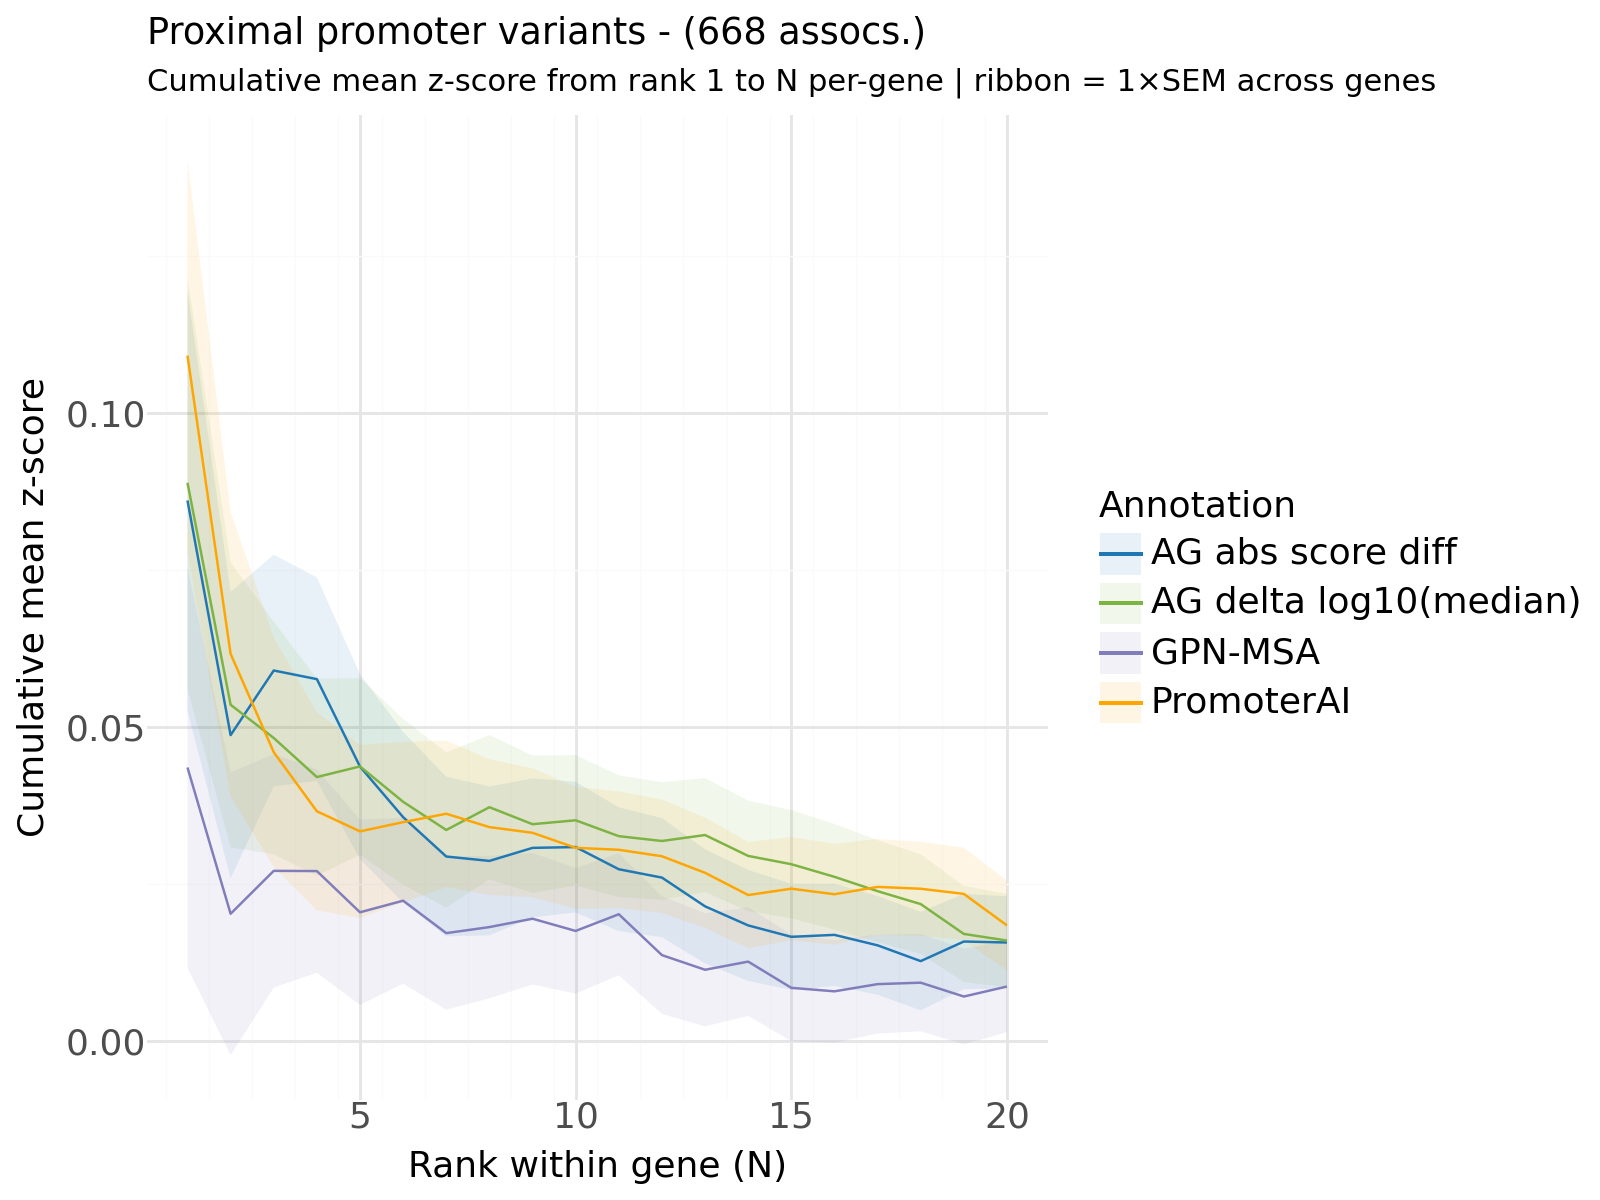

In [10]:
# Cumulative average z-score with proper per-gene SEM
# For each (annotation, region), compute cumulative mean up to ordinal rank N,
# then aggregate across genes to get mean and SEM at each N.
max_gene_rank = 20

if exclude_clinvar:
    plot_title = f"{vc['x_label']} (no ClinVar)"
elif only_clinvar:
    plot_title = f"{vc['x_label']} (only ClinVar)"
else:
    plot_title = vc['x_label']

cum_genewise_stats = (
    ranked_zscores_genewise.lazy()
    .filter(pl.col('ordinal_rank') <= max_gene_rank)
    .sort(['annotation', 'region', 'ordinal_rank'])
    .with_columns(
        cum_mean_pheno=(
            pl.col('mean_pheno_value_by_rank').cum_sum().over(['annotation', 'region'])
            / pl.col('ordinal_rank')
        )
    )
    .group_by(['annotation', 'ordinal_rank'])
    .agg(
        mean_cum_zscore=pl.col('cum_mean_pheno').mean(),
        std_cum_zscore =pl.col('cum_mean_pheno').std(),
        n_genes        =pl.col('region').n_unique(),
    )
    .with_columns(
        se_cum_zscore=pl.col('std_cum_zscore') / pl.col('n_genes').cast(pl.Float64).sqrt(),
    )
    .with_columns(
        ci_lower=pl.col('mean_cum_zscore') - ci_factor * pl.col('se_cum_zscore'),
        ci_upper=pl.col('mean_cum_zscore') + ci_factor * pl.col('se_cum_zscore'),
    )
    .join(anno_config_df.select(['annotation', 'label', 'color']).lazy(), on='annotation', how='left')
    .sort(['annotation', 'ordinal_rank'])
    .collect()
)

color_dict = dict(zip(cum_genewise_stats['label'], cum_genewise_stats['color']))

exclude_annos = ['promoterai_over', 'abexp_min', 'zooverphylop', 'zoopriphylop', 'abexp_max'] + ['priphylop', 'mamphylop'] + ['verphylop']
cum_genewise_stats = (
    cum_genewise_stats
    .filter(~pl.col('annotation').is_in(exclude_annos))
)

(
    ggplot(cum_genewise_stats, aes(x='ordinal_rank', y='mean_cum_zscore', color='label', fill='label'))
    + geom_ribbon(aes(ymin='ci_lower', ymax='ci_upper'), alpha=0.1, color='none')
    + geom_line()
    + scale_color_manual(values=color_dict)
    + scale_fill_manual(values=color_dict)
    + scale_x_continuous(minor_breaks=[x + 0.5 for x in range(max_gene_rank)])
    + labs(
        title=f"{plot_title} variants - ({ranked_zscores_genewise['region'].n_unique()} assocs.)",
        subtitle=f"Cumulative mean z-score from rank 1 to N per-gene | ribbon = {ci_factor}×SEM across genes",
        x="Rank within gene (N)",
        y="Cumulative mean z-score",
        color="Annotation",
        fill="Annotation",
    )
    + theme_minimal()
    + theme(
        figure_size=(8, 6),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13, lineheight=1.4),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        legend_background=element_rect(fill="white", color='white', alpha=0.8),
        plot_background=element_rect(fill="white", color="white"),
    )
)

In [11]:
cum_genewise_stats.filter(pl.col('ordinal_rank')==1)

annotation,ordinal_rank,mean_cum_zscore,std_cum_zscore,n_genes,se_cum_zscore,ci_lower,ci_upper,label,color
str,i32,f64,f64,u64,f64,f64,f64,str,str
"""abs_delta_log10_median_of_exon…",1,0.088894,0.839549,655,0.032804,0.05609,0.121698,"""AG delta log10(median)""","""#7CB342"""
"""abs_zscore_diff""",1,0.08607,0.855386,655,0.033423,0.052647,0.119493,"""AG abs score diff""","""#1f77b4"""
"""gpn_score""",1,0.04354,0.824573,668,0.031904,0.011636,0.075444,"""GPN-MSA""","""#807DBA"""
"""promoterai_under""",1,0.10915,0.808023,668,0.031263,0.077887,0.140414,"""PromoterAI""","""#FFA500"""


# Pair-wise significances Heatmaps

In [12]:
# --- Compute per-gene top-N mean z-scores for each N in target_k ---
target_k = np.array([5, 10], dtype=np.int64)

gene_topn_list = []
for n_val in target_k:
    gdf = (
        ranked_zscores_genewise.lazy()
        .filter(pl.col('ordinal_rank') <= n_val)
        .group_by(['region', 'annotation'])
        .agg(
            gene_topn_zscore = pl.col('mean_pheno_value_by_rank').mean(),
            n_variants_used  = pl.len(),
        )
        .with_columns(top_n = pl.lit(n_val, dtype=pl.Int64))
        .collect(engine='streaming')
    )
    gene_topn_list.append(gdf)

gene_topn = pl.concat(gene_topn_list)

# Drop genes where fewer than top_n variants were available (per annotation)
# gene_topn = gene_topn.filter(pl.col('n_variants_used') == pl.col('top_n'))

gene_topn

region,annotation,gene_topn_zscore,n_variants_used,top_n
str,str,f32,u64,i64
"""ENSG00000167202""","""promoterai_under""",-0.101254,5,5
"""ENSG00000084674""","""verphylop""",0.502735,5,5
"""ENSG00000119574""","""abexp_max""",-0.054129,5,5
"""ENSG00000112414""","""abexp_max""",0.016937,5,5
"""ENSG00000005801""","""abexp_max""",0.100641,5,5
…,…,…,…,…
"""ENSG00000159593""","""promoterai_under""",0.130403,10,10
"""ENSG00000160145""","""promoterai_under""",-0.479264,10,10
"""ENSG00000162063""","""promoterai_under""",-0.021578,10,10


In [13]:
# Drop genes not present in ALL annotations for a given top_n
# Ensures every pairwise comparison uses the same gene set → no gray boxes in heatmap
n_annos = gene_topn['annotation'].n_unique()
genes_in_all = (
    gene_topn
    .group_by(['region', 'top_n'])
    .agg(pl.n_unique('annotation').alias('n_annos'))
    .filter(pl.col('n_annos') == n_annos)
    .select(['region', 'top_n'])
)
# gene_topn = gene_topn.join(genes_in_all, on=['region', 'top_n'], how='semi')

print(f"Per-gene top-N z-scores shape (after filter): {gene_topn.shape}")

# --- 4. Track annotations ---
annotations_list = sorted(gene_topn['annotation'].unique().to_list())
print(f"Annotations: {annotations_list}")

Per-gene top-N z-scores shape (after filter): (13308, 5)
Annotations: ['abexp_max', 'abexp_min', 'abs_delta_log10_median_of_exon_medians', 'abs_zscore_diff', 'gpn_score', 'mamphylop', 'priphylop', 'promoterai_over', 'promoterai_under', 'verphylop']


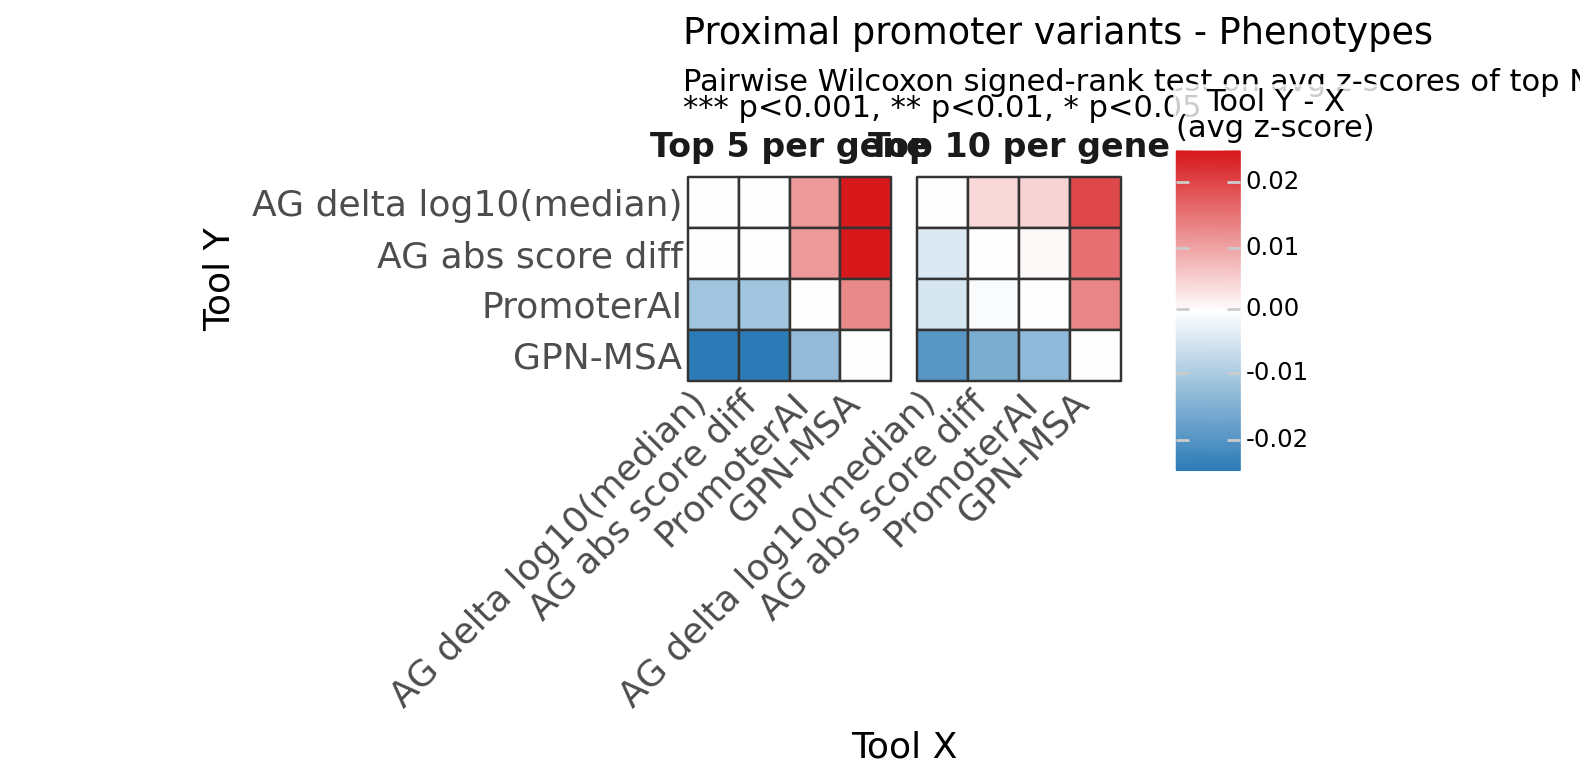

In [14]:
import pandas as pd
import itertools

# Build annotation name -> label mapping
anno_to_label = dict(zip(
    anno_config_df['annotation'].to_list(),
    anno_config_df['label'].to_list()
))

# Filter tools (exclude promoterai_over)
# plot_annotations = [a for a in annotations_list if a not in ['promoterai_over']]
plot_annotations = [a for a in annotations_list if a not in exclude_annos]

# 1. Order tools by mean gene z-score at smallest N (Top 5)
smallest_n = target_k[0]
tool_means = {}
# for ann in plot_annotations:
#     sub = gene_topn.filter(
#         (pl.col('annotation') == ann) & (pl.col('top_n') == smallest_n)
#     )
#     tool_means[ann] = float(sub['gene_topn_zscore'].mean())
tool_means = {}
for ann in plot_annotations:
    sub = gene_topn.filter(pl.col('annotation') == ann)
    tool_means[ann] = float(sub['gene_topn_zscore'].mean())


ordered_tools  = sorted(tool_means.keys(), key=lambda x: tool_means[x], reverse=True)
ordered_labels = [anno_to_label.get(t, t) for t in ordered_tools]

# 2. Pairwise Wilcoxon signed-rank test on paired per-gene z-scores
heatmap_data = []

for n_val in target_k:
    for ann_x, ann_y in itertools.product(ordered_tools, repeat=2):
        label_x = anno_to_label.get(ann_x, ann_x)
        label_y = anno_to_label.get(ann_y, ann_y)

        if ann_x == ann_y:
            heatmap_data.append({
                'Window': f"Top {n_val:,} per gene",
                'Window_Int': n_val,
                'Tool_X': label_x,
                'Tool_Y': label_y,
                'mean_diff': 0.0,
                'sig': ''
            })
            continue

        # Get paired gene z-scores (inner join → only genes present in both tools)
        df_x = gene_topn.filter(
            (pl.col('annotation') == ann_x) & (pl.col('top_n') == n_val)
        ).select(['region', 'gene_topn_zscore'])

        df_y = gene_topn.filter(
            (pl.col('annotation') == ann_y) & (pl.col('top_n') == n_val)
        ).select(['region', 'gene_topn_zscore'])

        paired = df_x.join(df_y, on='region', suffix='_y')
        z_x = paired['gene_topn_zscore'].to_numpy()
        z_y = paired['gene_topn_zscore_y'].to_numpy()

        mean_diff = float(z_y.mean() - z_x.mean())
        # median_diff = float(np.median(z_y) - np.median(z_x))

        if len(z_x) >= 10 and not np.allclose(z_x, z_y):
            _, p_val = stats.wilcoxon(z_x, z_y, alternative='two-sided')
        else:
            p_val = 1.0

        if p_val < 0.001: sig = '***'
        elif p_val < 0.01: sig = '**'
        elif p_val < 0.05: sig = '*'
        else: sig = ''

        heatmap_data.append({
            'Window': f"Top {n_val:,} per gene",
            'Window_Int': n_val,
            'Tool_X': label_x,
            'Tool_Y': label_y,
            'mean_diff': mean_diff,
            'sig': sig
        })

df_heat = pd.DataFrame(heatmap_data)
df_heat = df_heat.sort_values('Window_Int')

# Lock in the categorical order so best tools appear top/right
df_heat['Window'] = pd.Categorical(df_heat['Window'], categories=df_heat['Window'].unique(), ordered=True)
df_heat['Tool_X'] = pd.Categorical(df_heat['Tool_X'], categories=ordered_labels, ordered=True)
df_heat['Tool_Y'] = pd.Categorical(df_heat['Tool_Y'], categories=ordered_labels[::-1], ordered=True)

n_facets = len(target_k)
n_tools  = len(ordered_tools)

(
    ggplot(df_heat, aes(x='Tool_X', y='Tool_Y', fill='mean_diff'))
    + geom_tile(color="#333333", size=0.5)
    + geom_text(aes(label='sig'), color="black", size=12, va='center', nudge_y=-0.1)
    + facet_wrap('~Window', ncol=n_facets)
    + scale_fill_gradient2(low="#2C7BB6", mid="#FFFFFF", high="#D7191C", midpoint=0)
    + labs(
        title=f"{plot_title} variants - Phenotypes",
        subtitle="Pairwise Wilcoxon signed-rank test on avg z-scores of top N variants per gene\n*** p<0.001, ** p<0.01, * p<0.05",
        x="Tool X",
        y="Tool Y",
        fill="Tool Y - X\n(avg z-score)"
    )
    + theme_minimal()
    + theme(
        figure_size=(n_facets * (n_tools * 0.6 + 0.8) + 1.5, n_tools * 0.6 + 1.5),
        aspect_ratio=1,
        axis_title=element_text(size=13, lineheight=1.4),
        axis_text=element_text(size=13),
        axis_text_x=element_text(rotation=45, hjust=1),
        strip_text=element_text(size=12, face='bold'),
        panel_grid=element_blank(),
        legend_background=element_rect(fill="white", color='white', alpha=0.8),
        plot_background=element_rect(fill="white", color="white"),
    )
)